# Cyfrowe przetwarzanie sygnałów i obrazów – Laboratorium
## Przetwarzanie i analiza sygnału EKG

**Prowadzący:** Jacek Cichosz

**Katedra Systemów i Sieci Komputerowych, Politechnika Wrocławska, Wrocław**

**Autorzy:** *Yevhen Skyba, Andrii Kytrysh*

**Data:** *24.02.2026*

---

## Plan ćwiczeń laboratoryjnych

1. Platforma testowa
2. Testowe sygnały EKG
3. Analiza okresowych sygnałów w dziedzinie częstotliwości
4. Analiza sygnału EKG w dziedzinie częstotliwości
5. Filtracja sygnału EKG

---

## Wstęp teoretyczny

Elektrokardiogram (EKG) to zapis aktywności elektrycznej serca w czasie. Sygnał EKG jest sygnałem analogowym, który po próbkowaniu z częstotliwością $f_s$ przyjmuje postać dyskretną — ciągu próbek reprezentujących napięcie elektryczne mierzone przez elektrody.

Podstawowe parametry sygnału EKG:
- **Częstotliwość próbkowania ($f_s$)** — liczba próbek na sekundę [Hz]
- **Amplituda** — napięcie elektryczne [mV]
- **Odprowadzenie** — para elektrod mierząca różnicę potencjałów

W ćwiczeniu wykorzystano trzy pliki z sygnałami EKG:
- `ekg1.txt` — 12 odprowadzeń, $f_s = 1000$ Hz
- `ekg100.txt` — 1 odprowadzenie, $f_s = 360$ Hz
- `ekg_noise.txt` — 1 odprowadzenie z zakłóceniami, $f_s = 360$ Hz (format: czas, amplituda)

---


Wykorzystane biblioteki: `numpy`, `matplotlib`, `scipy`.

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

---

## Ćwiczenie 1 — Platforma testowa

Celem zadania jest stworzenie skryptu umożliwiającego wczytywanie, wizualizację oraz zapis wycinków sygnałów EKG. Skrypt obsługuje różne formaty plików wejściowych oraz pozwala na wybór przedziału czasowego i odprowadzenia.


### Sygnał 1 — `ekg1.txt`

Plik zawiera 12 kolumn odpowiadających 12 odprowadzeniom EKG oraz 5000 wierszy (próbek). Częstotliwość próbkowania wynosi $f_s = 1000$ Hz, co oznacza że sygnał trwa 5 sekund.

Czas trwania sygnału obliczany jest automatycznie na podstawie liczby próbek i częstotliwości próbkowania. Oś czasu generowana jest przez `np.arange()` z krokiem $\frac{1}{f_s}$. Wycinek sygnału wyznaczany jest za pomocą maski logicznej — tablicy wartości `True/False` wskazującej które próbki należą do zadanego przedziału czasowego.

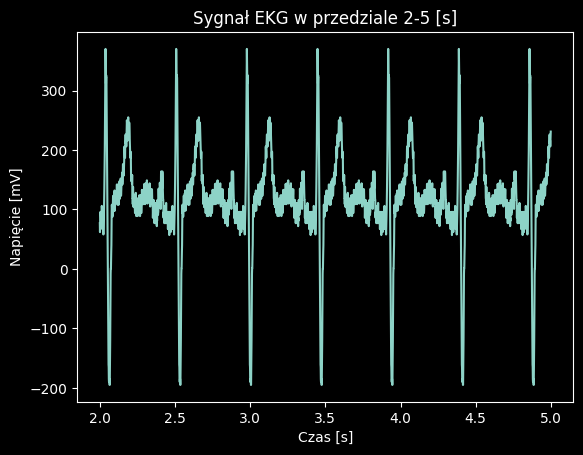

In [113]:
ekg = np.loadtxt('./signals/ekg1.txt')

t_start = 2
t_end = 5
fs = 1000

channeling = 0

duration = ekg.shape[0] / fs
time = np.arange(0, duration, 1/fs)
mask = (time >= t_start) & (time <= t_end)
plt.xlabel("Czas [s]")
plt.ylabel("Napięcie [mV]")
plt.title(f"Sygnał EKG w przedziale {t_start}-{t_end} [s]")
plt.plot(time[mask], ekg[mask, channeling])

np.savetxt(f"./task1_results/ekg1-{t_start}-{t_end}-wszystkie.txt", np.column_stack((time[mask], ekg[mask, :])))
np.savetxt(f"./task1_results/ekg1-{t_start}-{t_end}-odprowadzenie.txt", np.column_stack((time[mask], ekg[mask, channeling])))

plt.show()



### Sygnał 2 — `ekg100.txt`

Plik zawiera pojedyncze odprowadzenie EKG — jedną kolumnę wartości amplitud. Częstotliwość próbkowania wynosi $f_s = 360$ Hz, a sygnał trwa około 1805 sekund.

W porównaniu do sygnału 1 wprowadzono dwie zmiany. Po pierwsze, tablica `dane` jest jednowymiarowa, więc nie można używać notacji `dane[mask, kolumna]` — wystarczy samo `dane[mask]`. Po drugie, zmieniono wartość `fs` na 360.


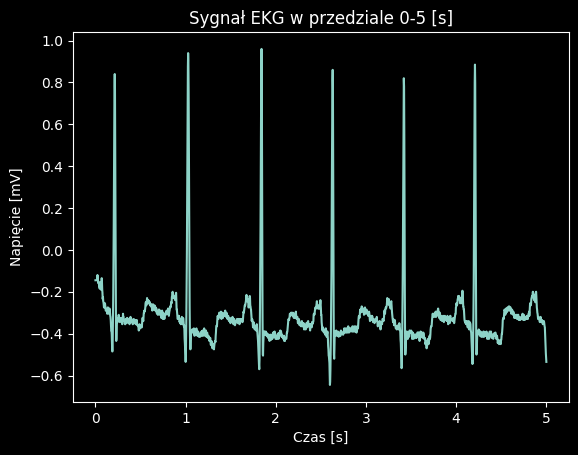

In [114]:
ekg = np.loadtxt('./signals/ekg100.txt')

t_start = 0
t_end = 5
fs = 360

duration = ekg.shape[0] / fs
time = np.arange(0, duration, 1/fs)
mask = (time >= t_start) & (time <= t_end)
plt.xlabel("Czas [s]")
plt.ylabel("Napięcie [mV]")
plt.title(f"Sygnał EKG w przedziale {t_start}-{t_end} [s]")
plt.plot(time[mask], ekg[mask])

np.savetxt(f"./task1_results/ekg100-{t_start}-{t_end}.txt", np.column_stack((time[mask], ekg[mask])))

plt.show()



### Sygnał 3 — `ekg_noise.txt`

Plik zawiera dwie kolumny: pierwsza to momenty czasu [s], druga to wartości amplitud [mV]. Częstotliwość próbkowania wynosi $f_s = 360$ Hz.

W tym przypadku oś czasu nie jest generowana przez `np.arange()` — jest bezpośrednio odczytywana z pierwszej kolumny pliku (`ekg[:, 0]`). Amplituda pochodzi z drugiej kolumny (`ekg[:, 1]`). Maska jest konstruowana tak samo jak poprzednio.

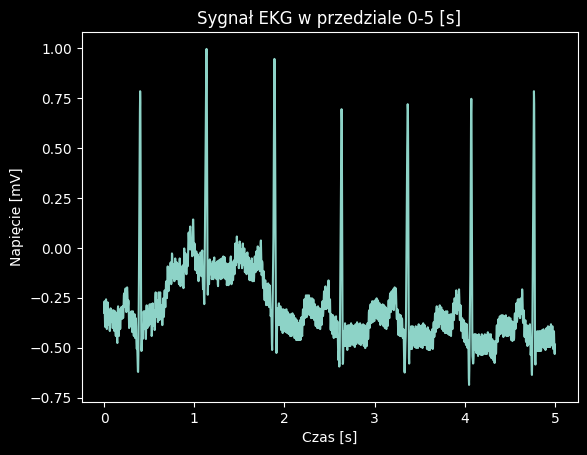

In [115]:
ekg = np.loadtxt('./signals/ekg_noise.txt')

t_start = 0
t_end = 5
fs = 360

duration = ekg.shape[0] / fs
time = ekg[:, 0]
mask = (time >= t_start) & (time <= t_end)
plt.xlabel("Czas [s]")
plt.ylabel("Napięcie [mV]")
plt.title(f"Sygnał EKG w przedziale {t_start}-{t_end} [s]")
plt.plot(time[mask], ekg[mask, 1])

np.savetxt(f"./task1_results/ekg-noise-{t_start}-{t_end}.txt", np.column_stack((time[mask], ekg[mask])))

plt.show()

---

## Ćwiczenie 2 — Analiza sygnałów okresowych w dziedzinie częstotliwości

Celem ćwiczenia jest praktyczne zastosowanie funkcji `numpy.fft` i `numpy.ifft` do wyznaczania prostej i odwrotnej dyskretnej transformaty Fouriera. Transformata Fouriera rozkłada sygnał na składowe częstotliwości — jej wynikiem jest **widmo amplitudowe**, które pokazuje które częstotliwości dominują w sygnale.


### Punkt 1 — Generowanie sinusoidy 50 Hz

Wygenerowano falę sinusoidalną o częstotliwości $f = 50$ Hz i długości $N = 65536$ próbek przy częstotliwości próbkowania $f_s = 1000$ Hz. Sygnał opisany jest wzorem:

$$y(t) = \sin(2\pi f t)$$

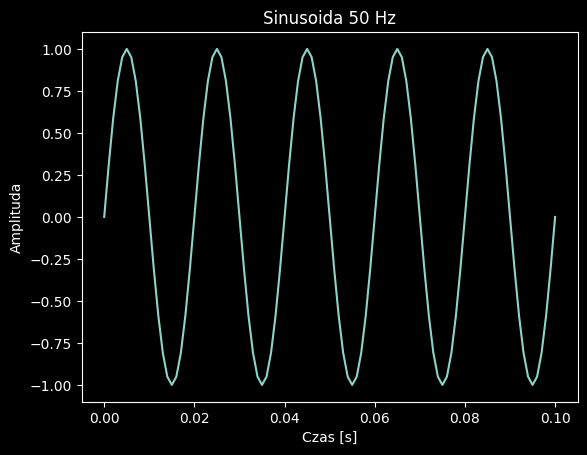

In [116]:
fs = 1000
f = 50
t = np.arange(0, 65536/fs, 1/fs)
y = np.sin(2 * np.pi * f * t)

mask = (t >= 0) & (t <= 0.1)
plt.title(f"Sinusoida {f} Hz")
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.plot(t[mask], y[mask])
plt.show()

Na wykresie przedstawiono wycinek sygnału w przedziale $[0, 0.1]$ s, na którym widocznych jest 5 pełnych okresów sinusoidy.

### Punkt 2 — Widmo amplitudowe sinusoidy 50 Hz

Wyznaczono dyskretną transformatę Fouriera sygnału za pomocą `np.fft.fft()`. Ponieważ wynik FFT zawiera liczby zespolone, do wyznaczenia widma amplitudowego użyto funkcji `np.abs()`. Oś częstotliwości wygenerowano przez `np.fft.fftfreq()`, a wykres ograniczono do zakresu $[0, f_s/2]$.


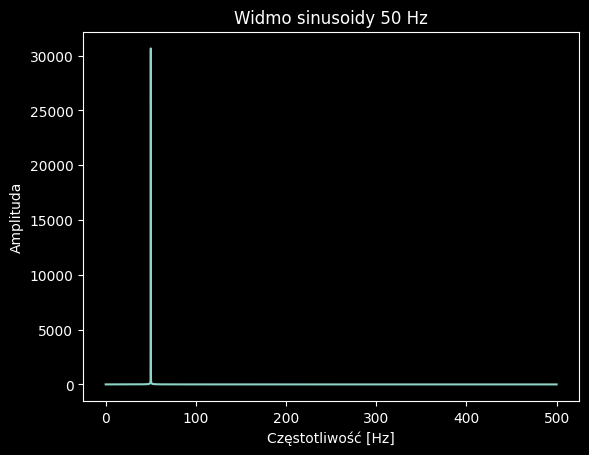

In [117]:
freqs = np.fft.fftfreq(len(y), 1/fs)
mask_freq = freqs >= 0

plt.title(f"Widmo sinusoidy {f} Hz")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
plt.plot(freqs[mask_freq], np.abs(np.fft.fft(y))[mask_freq])
plt.show()

Na widmie widoczny jest pojedynczy pik przy $f = 50$ Hz, co potwierdza że sygnał składa się z jednej składowej częstotliwości.

### Punkt 3 — Widmo mieszaniny dwóch sinusoid

Wygenerowano kombinację liniową dwóch fal sinusoidalnych o częstotliwościach $f_1 = 50$ Hz i $f_2 = 60$ Hz:

$$y(t) = \sin(2\pi f_1 t) + \sin(2\pi f_2 t)$$

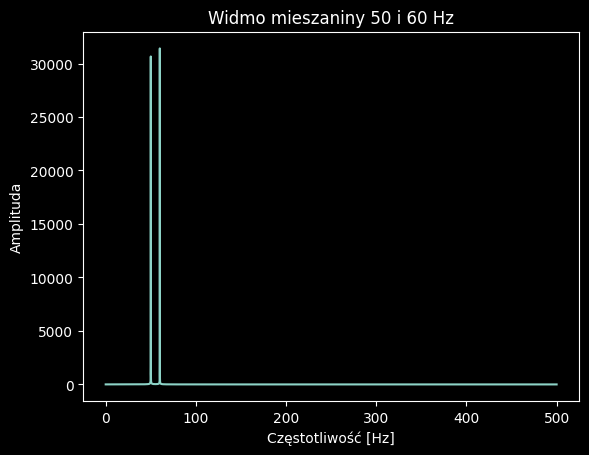

In [118]:
f1, f2 = 50, 60
y = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

plt.title(f"Widmo mieszaniny {f1} i {f2} Hz")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
plt.plot(freqs[mask_freq], np.abs(np.fft.fft(y))[mask_freq])
plt.show()

Na widmie amplitudowym widoczne są dwa piki — przy 50 Hz i 60 Hz — co potwierdza że transformata Fouriera poprawnie rozłożyła sygnał na dwie składowe częstotliwości.

### Punkt 4 — Wpływ częstotliwości próbkowania na widmo

Eksperyment powtórzono dla różnych częstotliwości próbkowania: $f_s \in \{200, 500, 1000, 5000\}$ Hz. Wraz ze wzrostem $f_s$ zakres osi częstotliwości rozszerza się (do $f_s/2$), a piki przy 50 i 60 Hz pozostają w tych samych miejscach. Przy niższych $f_s$ piki są wyraźniej rozdzielone względem całej skali, przy wyższych $f_s$ skupiają się blisko zera.

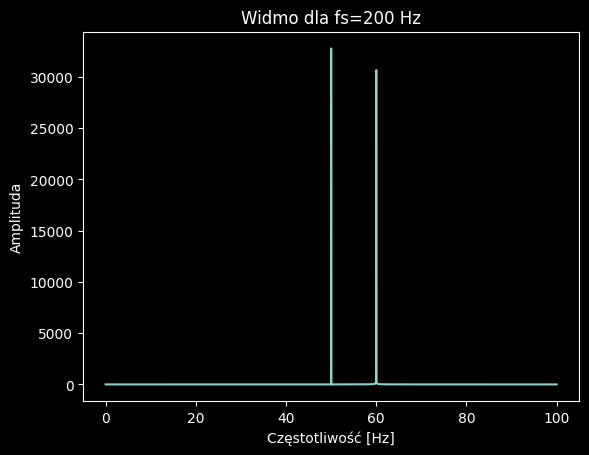

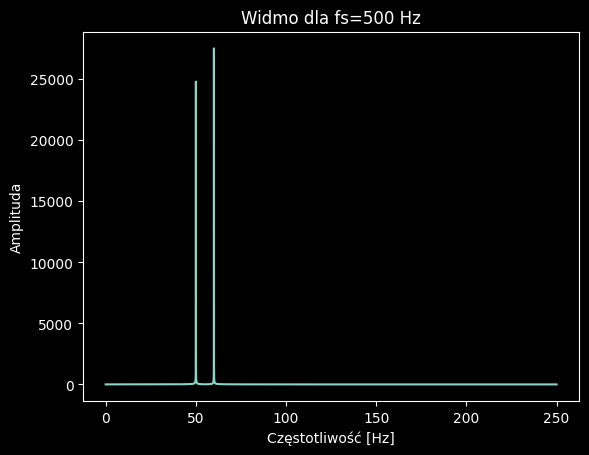

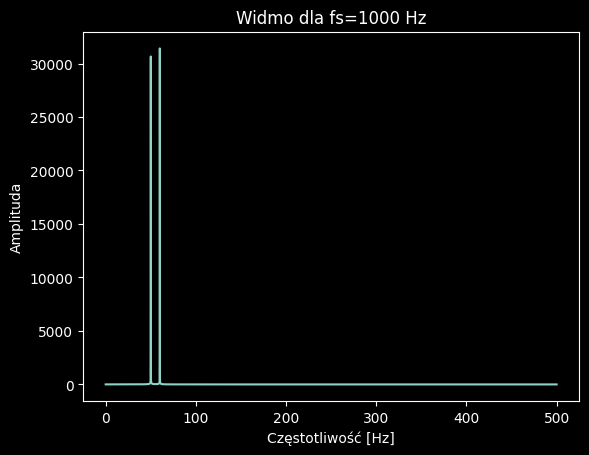

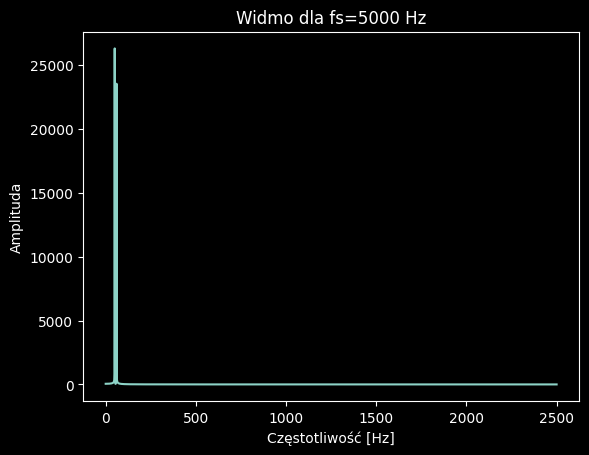

In [119]:
for fs in [200, 500, 1000, 5000]:
    t = np.arange(0, 65536/fs, 1/fs)
    y = np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 60 * t)
    freqs = np.fft.fftfreq(len(y), 1/fs)
    mask_freq = freqs >= 0

    plt.figure()
    plt.title(f"Widmo dla fs={fs} Hz")
    plt.xlabel("Częstotliwość [Hz]")
    plt.ylabel("Amplituda")
    plt.plot(freqs[mask_freq], np.abs(np.fft.fft(y))[mask_freq])
    plt.show()

### Punkt 5 — Odwrotna transformata Fouriera

Wyznaczono odwrotną transformatę Fouriera (`np.fft.ifft()`) sygnału otrzymanego w punkcie 2. Porównano sygnał odtworzony z oryginalnym — oba wykresy pokrywają się idealnie, co oznacza że transformata Fouriera jest operacją odwracalną i nie powoduje utraty informacji.

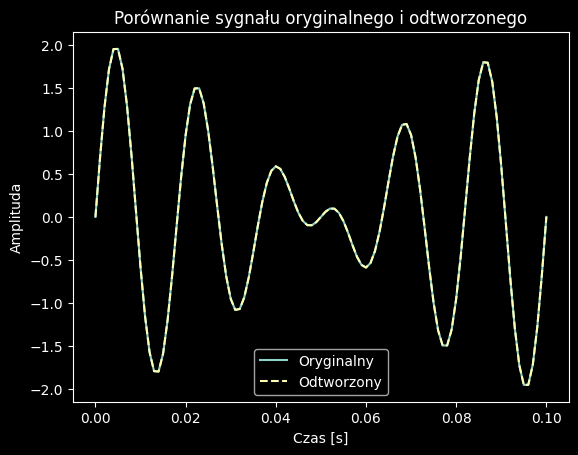

In [120]:
fs = 1000
t = np.arange(0, 65536/fs, 1/fs)
mask = (t >= 0) & (t <= 0.1)

y = np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 60 * t)
Y = np.fft.fft(y)
y_odtworzone = np.fft.ifft(Y)

plt.title("Porównanie sygnału oryginalnego i odtworzonego")
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.plot(t[mask], y[mask], label="Oryginalny")
plt.plot(t[mask], np.real(y_odtworzone[mask]), label="Odtworzony", linestyle="--")
plt.legend()
plt.show()

---

## Ćwiczenie 3 — Analiza sygnału EKG w dziedzinie częstotliwości

Celem ćwiczenia jest obserwacja widma amplitudowego rzeczywistego sygnału EKG oraz weryfikacja poprawności odwrotnej transformaty Fouriera.

### Punkt 1 — Wczytanie i wizualizacja sygnału

Wczytano sygnał `ekg100.txt` (jedna kolumna, $f_s = 360$ Hz) i przedstawiono wycinek w przedziale $[0, 5]$ s. Na wykresie widoczne są charakterystyczne piki QRS odpowiadające kolejnym uderzeniom serca, występujące regularnie co około 0.75 s (ok. 80 uderzeń/min).

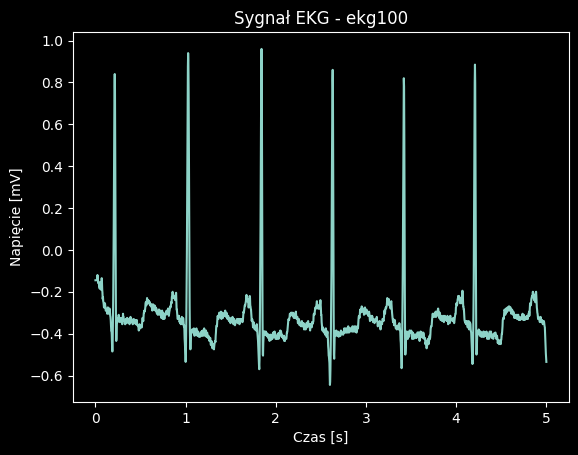

In [121]:
fs = 360
ekg = np.loadtxt('./signals/ekg100.txt')

duration = ekg.shape[0] / fs
t = np.arange(0, duration, 1/fs)
mask = (t >= 0) & (t <= 5)

plt.figure()
plt.title("Sygnał EKG - ekg100")
plt.xlabel("Czas [s]")
plt.ylabel("Napięcie [mV]")
plt.plot(t[mask], ekg[mask])
plt.show()

### Punkt 2 — Widmo amplitudowe sygnału EKG

Wyznaczono dyskretną transformatę Fouriera sygnału i przedstawiono widmo amplitudowe w zakresie $[0, f_s/2] = [0, 180]$ Hz. Dominująca energia sygnału skupiona jest przy niskich częstotliwościach (blisko 0 Hz), co odpowiada wolnozmiennym składowym sygnału EKG. Piki QRS odpowiadają składowym o wyższych częstotliwościach, jednak ich amplituda jest znacznie mniejsza.

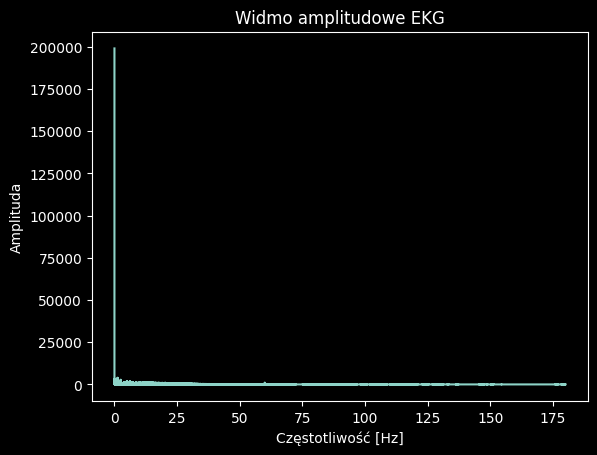

In [122]:
freqs = np.fft.fftfreq(len(ekg), 1/fs)
mask_freq = freqs >= 0

plt.figure()
plt.title("Widmo amplitudowe EKG")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
plt.plot(freqs[mask_freq], np.abs(np.fft.fft(ekg))[mask_freq])
plt.show()

### Punkt 3 — Odwrotna transformata Fouriera i porównanie sygnałów

Wyznaczono odwrotną transformatę Fouriera (`np.fft.ifft()`) i porównano sygnał odtworzony z oryginalnym. Wykresy pokrywają się idealnie. Różnica między sygnałami wynosi rzędu $10^{-16}$, co jest jedynie błędem numerycznym arytmetyki zmiennoprzecinkowej — w praktyce równym zeru. Potwierdza to że transformata Fouriera jest operacją odwracalną bez utraty informacji.

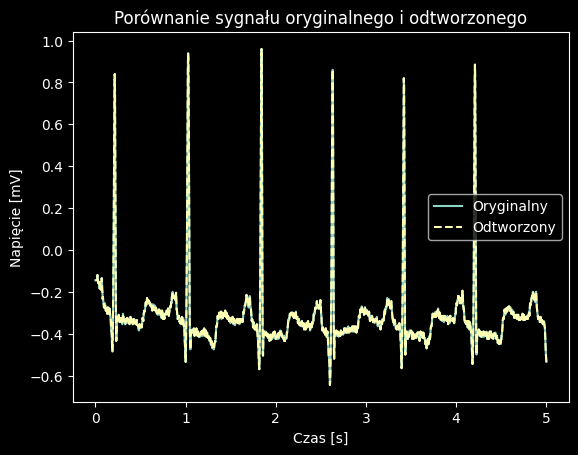

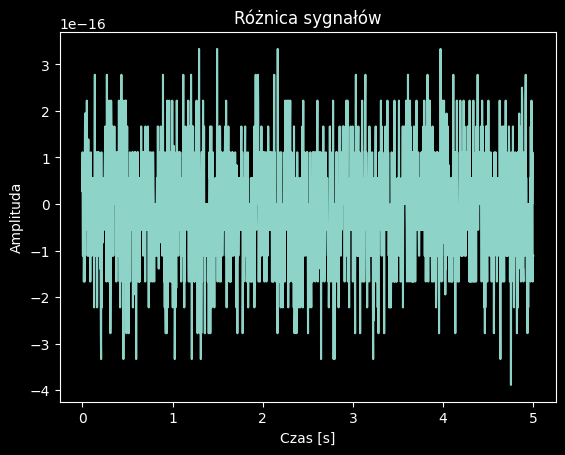

In [123]:
Y = np.fft.fft(ekg)
reconstructed = np.fft.ifft(Y)
difference = ekg - np.real(reconstructed)

plt.figure()
plt.title("Porównanie sygnału oryginalnego i odtworzonego")
plt.xlabel("Czas [s]")
plt.ylabel("Napięcie [mV]")
plt.plot(t[mask], ekg[mask], label="Oryginalny")
plt.plot(t[mask], np.real(reconstructed[mask]), label="Odtworzony", linestyle="--")
plt.legend()
plt.show()

plt.figure()
plt.title("Różnica sygnałów")
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.plot(t[mask], difference[mask])
plt.show()

---

## Ćwiczenie 4 — Filtracja sygnału EKG

Celem ćwiczenia jest eliminacja niepożądanych zakłóceń z sygnału EKG przy użyciu filtrów cyfrowych. Zastosowano filtr Butterwortha z biblioteki `scipy.signal`. Filtr Butterwortha charakteryzuje się maksymalnie płaską charakterystyką w paśmie przepustowym.

### Punkt 1 — Wczytanie sygnału z zakłóceniami

Wczytano sygnał `ekg_noise.txt` ($f_s = 360$ Hz, dwie kolumny: czas i amplituda).

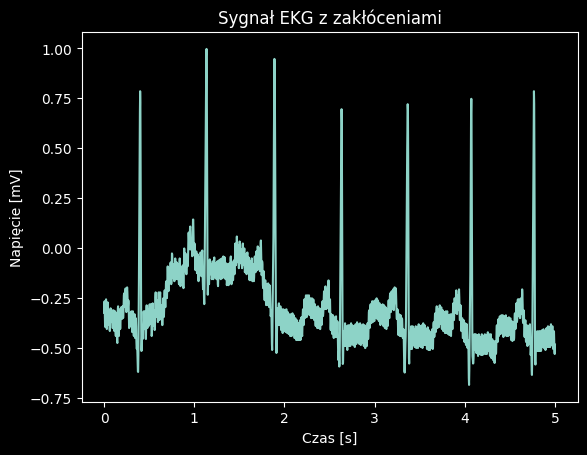

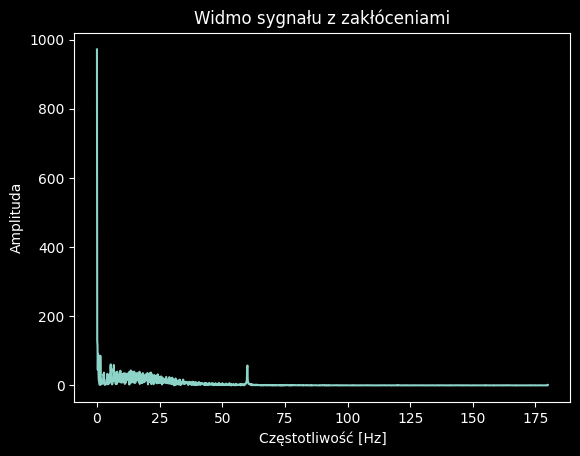

In [124]:
fs = 360

data = np.loadtxt('./signals/ekg_noise.txt')
t = data[:, 0]
ekg = data[:, 1]

mask = (t >= 0) & (t <= 5)

plt.figure()
plt.title("Sygnał EKG z zakłóceniami")
plt.xlabel("Czas [s]")
plt.ylabel("Napięcie [mV]")
plt.plot(t[mask], ekg[mask])
plt.show()

freqs = np.fft.fftfreq(len(ekg), 1/fs)
mask_freq = freqs >= 0

plt.figure()
plt.title("Widmo sygnału z zakłóceniami")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
plt.plot(freqs[mask_freq], np.abs(np.fft.fft(ekg))[mask_freq])
plt.show()

* Na wykresie sygnału widoczne są zakłócenia — sygnał jest "rozmyty" i obserwuje się powolne dryftowanie linii bazowej (pływanie linii izoelektrycznej).
 * Na widmie amplitudowym widoczny jest wyraźny pik przy ~60 Hz, pochodzący z zakłóceń sieci zasilającej.

### Punkt 2 — Filtr dolnoprzepustowy 60 Hz

Zastosowano filtr Butterwortha 4. rzędu z częstotliwością graniczną $f_c = 60$ Hz w celu redukcji zakłóceń z sieci zasilającej. Funkcja `butter()` wyznacza współczynniki filtra, a `filtfilt()` stosuje go do sygnału bez przesunięcia fazowego.

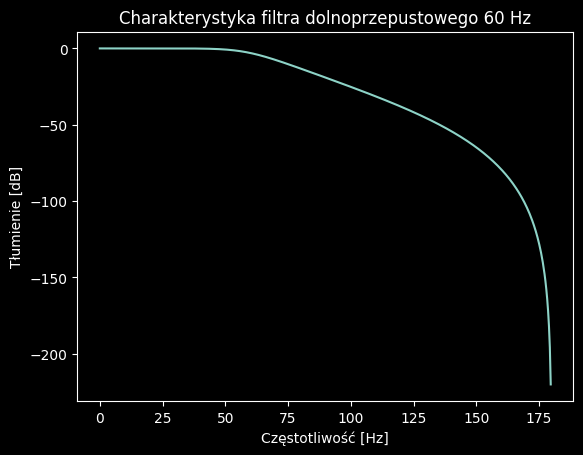

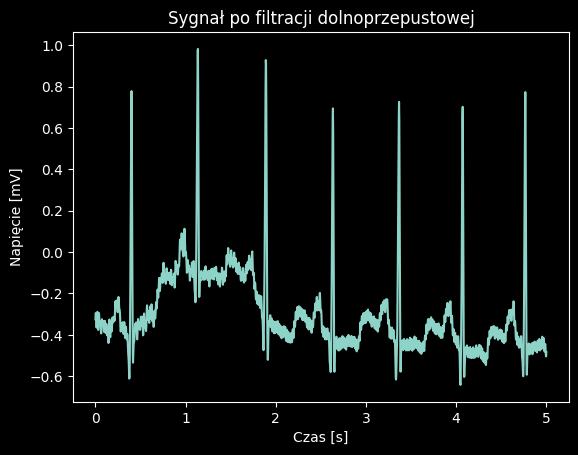

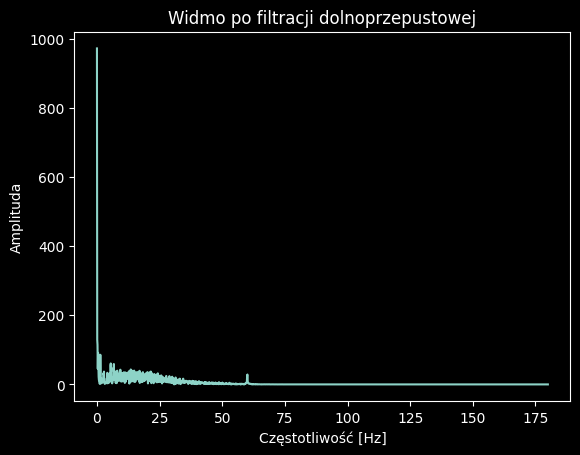

In [125]:
b, a = signal.butter(4, 60, btype='low', fs=fs)
ekg_low = signal.filtfilt(b, a, ekg)

w, h = signal.freqz(b, a, fs=fs)
plt.figure()
plt.title("Charakterystyka filtra dolnoprzepustowego 60 Hz")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Tłumienie [dB]")
plt.plot(w, 20 * np.log10(abs(h)))
plt.show()

plt.figure()
plt.title("Sygnał po filtracji dolnoprzepustowej")
plt.xlabel("Czas [s]")
plt.ylabel("Napięcie [mV]")
plt.plot(t[mask], ekg_low[mask])
plt.show()

plt.figure()
plt.title("Widmo po filtracji dolnoprzepustowej")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
plt.plot(freqs[mask_freq], np.abs(np.fft.fft(ekg_low))[mask_freq])
plt.show()

Na charakterystyce filtra widać że tłumienie rośnie powyżej 60 Hz. Po filtracji pik przy 60 Hz na widmie znacznie się zmniejszył, a sygnał w dziedzinie czasu stał się gładszy — usunięto szybkozmienne zakłócenia.

### Punkt 3 — Filtr górnoprzepustowy 5 Hz

Do sygnału otrzymanego w punkcie 2 zastosowano filtr Butterwortha 4. rzędu górnoprzepustowy z częstotliwością graniczną $f_c = 5$ Hz, w celu eliminacji pływania linii izoelektrycznej (wolnozmiennego dryfu sygnału).

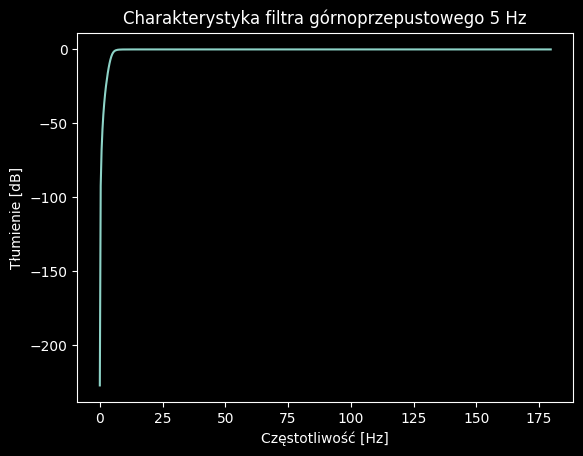

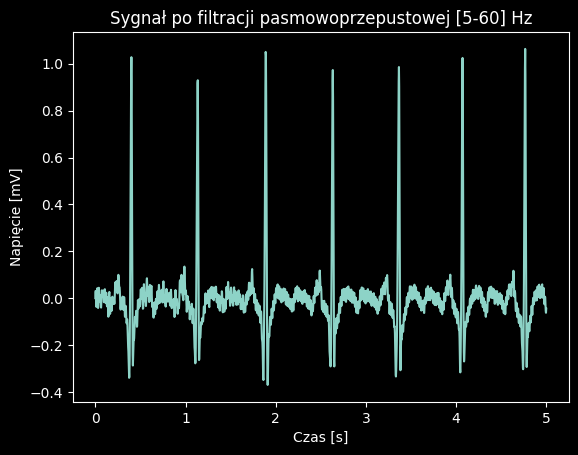

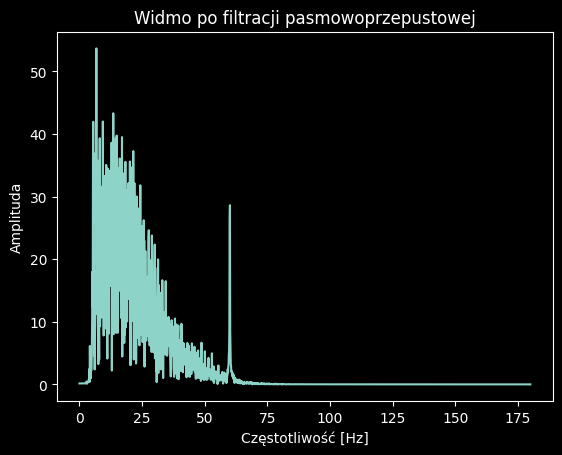

In [126]:
b2, a2 = signal.butter(4, 5, btype='high', fs=fs)
ekg_band = signal.filtfilt(b2, a2, ekg_low)

w2, h2 = signal.freqz(b2, a2, fs=fs)
plt.figure()
plt.title("Charakterystyka filtra górnoprzepustowego 5 Hz")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Tłumienie [dB]")
plt.plot(w2, 20 * np.log10(abs(h2)))
plt.show()

plt.figure()
plt.title("Sygnał po filtracji pasmowoprzepustowej [5-60] Hz")
plt.xlabel("Czas [s]")
plt.ylabel("Napięcie [mV]")
plt.plot(t[mask], ekg_band[mask])
plt.show()

plt.figure()
plt.title("Widmo po filtracji pasmowoprzepustowej")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
plt.plot(freqs[mask_freq], np.abs(np.fft.fft(ekg_band))[mask_freq])
plt.show()

Szeregowe połączenie filtra dolnoprzepustowego (60 Hz) i górnoprzepustowego (5 Hz) jest równoważne filtrowi pasmowoprzepustowemu o paśmie przepustowym $[5, 60]$ Hz. Na wykresie końcowego sygnału widać wyraźne piki QRS, a linia bazowa przebiega stabilnie wokół zera. Widmo potwierdza że energia sygnału skupiona jest w paśmie $[5, 60]$ Hz.

---

## Wnioski

Ćwiczenia pozwoliły na praktyczne zapoznanie się z podstawowymi metodami przetwarzania sygnałów EKG w dziedzinie czasu i częstotliwości.

**Ćwiczenie 1** — Platforma testowa umożliwiła wczytywanie i wizualizację sygnałów EKG w różnych formatach. Kluczowym elementem było przeliczanie indeksów próbek na czas w sekundach przy użyciu częstotliwości próbkowania $f_s$, co pozwala na porównywanie sygnałów niezależnie od ich formatu.

**Ćwiczenie 2** — Dyskretna transformata Fouriera rozkłada sygnał na składowe częstotliwości. Dla sinusoidy o częstotliwości 50 Hz widmo amplitudowe zawiera pojedynczy pik w tym miejscu. Dla mieszaniny dwóch sinusoid (50 i 60 Hz) widoczne są dwa piki, co potwierdza że FFT poprawnie identyfikuje wszystkie składowe częstotliwości sygnału. Odwrotna transformata Fouriera odtworzyła sygnał z dokładnością rzędu $10^{-16}$, co oznacza że operacja jest praktycznie bezstratna.

**Ćwiczenie 3** — Widmo amplitudowe rzeczywistego sygnału EKG skupia energię przy niskich częstotliwościach, co odpowiada wolnozmiennym składowym sygnału serca. Podobnie jak w zadaniu 2, odwrotna FFT odtworzyła sygnał z błędem numerycznym rzędu $10^{-16}$.

**Ćwiczenie 4** — Filtracja sygnału EKG filtrem Butterwortha skutecznie wyeliminowała zakłócenia. Filtr dolnoprzepustowy (60 Hz) usunął zakłócenia z sieci zasilającej widoczne jako pik przy 60 Hz w widmie. Filtr górnoprzepustowy (5 Hz) wyeliminował pływanie linii izoelektrycznej. Szeregowe połączenie obu filtrów jest równoważne filtrowi pasmowoprzepustowemu $[5, 60]$ Hz, który przepuszcza tylko częstotliwości istotne diagnostycznie dla sygnału EKG.

## Literatura

1. Dyskretna transformacja Fouriera: [numpy.fft](https://docs.scipy.org/doc/numpy/reference/routines.fft.html), 2020
2. W. Myszka. Jupyter: [Instrukcja Jupyter](https://kmim.wm.pwr.edu.pl/myszka/dydaktyka/metodynumeryczne/dodatki/jupyter/), 2020
3. W. Myszka. Szybka transformata Fouriera: [FFT Notebook](https://nbviewer.jupyter.org/urls/temisto.immt.pwr.wroc.pl/~myszka/Jupyter/FFT.ipynb), 2020
4. Numpy Tutorial: [cs231n.github.io](http://cs231n.github.io/python-numpy-tutorial/), 2020
5. Samouczek Pythona: [learnpython.org](https://www.learnpython.org/pl/), 2020
6. Scipy Lecture Notes: [scipy-lectures.org](https://scipy-lectures.org/), 2020
7. scipy.signal: [docs.scipy.org](https://docs.scipy.org/doc/scipy/reference/signal.html), 2020
8. The Python Tutorial: [docs.python.org](https://docs.python.org/3/tutorial/), 2020